In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import pickle
import sinter
from copy import deepcopy
import scipy

import src.device as device
import src.plotting as plotter
import src.stim_dag as stim_dag

from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.TileCode import TileCode
from src.HGPCode import HGPCode
from src.RadialCode import RadialCode
from src.GBCode import GBCode
from src.HypercubeCode import HypercubeCode
from src.decoders import BPOSD

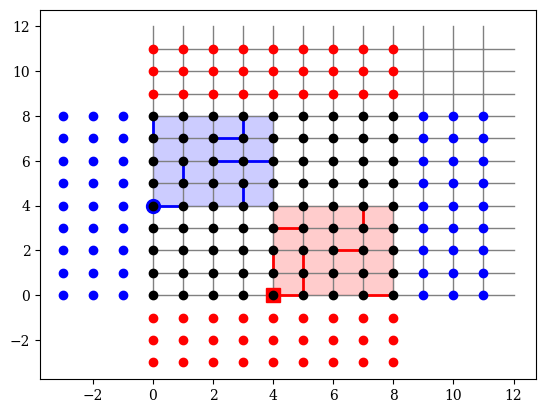

In [2]:
code_tile = TileCode.known_code(288, 18, 13)
code_tile.plot_construction()

In [3]:
len(code_tile._qubit_edges)

288

In [5]:
code_tile = TileCode.known_code(512, 18, 19)

buffer = 3
xmax,ymax = 0,0
data_coords = dict()
for i in code_tile.data_indices:
    x,y = code_tile.qubit_coords[i]
    data_coords[i] = (x+buffer, y+buffer)
    xmax = max(xmax, x)
    ymax = max(ymax, y)

dev = device.UnitCellDevice(xmax+2*buffer, ymax+2*buffer, device.default_hwp, debug=False)

sched_tile = dev.compile_QEC_schedule(
    code_tile,
    data_coords,
    [],
    rounds=13,
    use_highways=True,
    refocus_shuttle_noise=False,
    separate_X_Z=True,
)

circ = sched_tile.to_stim_circuit(code_tile, 'X', device.error_params(1e-3, 1e-3, 1e-3), XYZ_decode=False)

circ.detector_error_model()

Optimizing 247 ancilla schedules.......................................................................................................................................................................................................................................................
Optimizing 247 ancilla schedules.......................................................................................................................................................................................................................................................


stim.DetectorErrorModel('''
    error(0.0020308) D0 D28 D138 D147
    error(0.00272771) D0 D43 D52 D100
    error(0.00820581) D0 D253
    error(0.0020308) D1 D29 D128 D245
    error(0.0020308) D1 D49 D52 D116
    error(0.00820581) D1 D257
    error(0.0020308) D2 D27 D116 D153
    error(0.0020308) D2 D40 D51 D143
    error(0.00820581) D2 D258
    error(0.0020308) D3 D38 D147 D246
    error(0.0020308) D3 D41 D51 D99
    error(0.00820581) D3 D250
    error(0.0020308) D4 D35 D116 D244
    error(0.0020308) D4 D43 D47 D246
    error(0.00820581) D4 D248
    error(0.0020308) D5 D34 D100 D245
    error(0.0020308) D5 D41 D47 D153
    error(0.00820581) D5 D255
    error(0.0020308) D6 D33 D244 L0 L2 L6 L9 L12 L13 L14 L16 L17
    error(0.0020308) D6 D44 D49 D147
    error(0.00820581) D6 D252
    error(0.0020308) D7 D44 D45 D245
    error(0.0020308) D7 D138 L1 L3 L4 L6 L11 L12 L14 L15 L17
    error(0.00820581) D7 D249
    error(0.0020308) D8
    error(0.0020308) D8 D31 D153 D202
    error(0.00820581